# **Total Perspective Vortex**
## **Goals**
**Total perspective vortex** is a 42 school project, which goal is to create a brain computer interface based on the **EEG** data from [physionet](https://physionet.org/content/eegmmidb/1.0.0/).
The main goal is to create a [**dimensionality reduction algorithm**](https://en.wikipedia.org/wiki/Dimensionality_reduction) and create a **benchmark** with different **machine learning (ML)** algorithm, using **scikit learn** **pipeline object**.

Those ML **algorithm** will be used to **predict**, in real time, which **movement** the patient will do (move his feets. his hands, ...).

## **Resources**
### EEG data
- [The project data set.](https://physionet.org/content/eegmmidb/1.0.0/S001/#files-panel)
- [Physionet signal visualizer.](https://physionet.org/lightwave/?db=eegmmidb/1.0.0)
- [MNE website.](https://mne.tools/stable/index.html)
### Data filtering
- [Article that explain data filtering.](https://medium.com/@acamvproducingstudio/how-do-filters-work-and-how-to-simulate-them-signals-and-systems-review-part4-f6a978cefca3)
- [Wikipedia page of the low pass filter](https://en.wikipedia.org/wiki/Low-pass_filter)
- [MNE explanation of filtering](https://mne.tools/stable/auto_tutorials/preprocessing/30_filtering_resampling.html)
### Dimensionality reduction
- [Dimensionality reduction Wikipedia page.](https://en.wikipedia.org/wiki/Dimensionality_reduction)
- [IBM article about dimensionality reduction.](https://www.ibm.com/think/topics/dimensionality-reduction)
- [Article with explanation and use of different dimensionality reduction.](https://pmc.ncbi.nlm.nih.gov/articles/PMC12453773/)

In [1]:
import numpy as np
import mne
import pathlib as pth
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker
from dataclasses import dataclass

from low_pass_filter import low_pass_filter

## 1.0 Extracting the data.

### Dataset description:
The current data set is composed of 109 subjects that where tested, with 14 test, each with 64 electrodes.
So in terms of architecture, it looks like this:
```
S001
├── S001R01.edf
│   └── data shape -> (64, ...)
├── S001R01.edf.event
[...]
├── S001R14.edf
│   └── data shape -> (64, ...)
└── S001R14.edf.event
```

Each test are split in 3 different parts: T0 (Idle), T1 (Action 1), T2 (Action 2).

These actions are done in range of 2 minutes each.

In [26]:
data_folder = pth.Path('eeg-motor-movementimagery-dataset-1.0.0/files')

# Change with a iterdir loop or a data selector.
s001 = data_folder / 'S001'

s001r01 = s001 / 'S001R06.edf'
raw = mne.io.read_raw_edf(s001r01)
raw_events = mne.events_from_annotations(raw)

data = raw.get_data()

@dataclass(frozen=True)
class Event:
    type:       int
    type_str:   str
    arr:        np.ndarray
    time:       np.ndarray

split_events = [
    Event(
        start[2],
        list(raw_events[1].keys())[list(raw_events[1].values()).index(start[2])],
        data[:, start[0]:end[0]],
        raw.times[start[0]:end[0]]
    ) for start, end in zip(raw_events[0][:-1, :], raw_events[0][1:, :])]

Extracting EDF parameters from eeg-motor-movementimagery-dataset-1.0.0/files/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


## 1.1 Data analyse
### Raw signal

Since we now have extracted the raw data of the file, we can see what the signals look like.

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_1254882/1277427908.py:14: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=80).plot()
/home/mhaouas/Documents/42PostCC/total-perspective-vortex/.venv/lib/python3.10/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


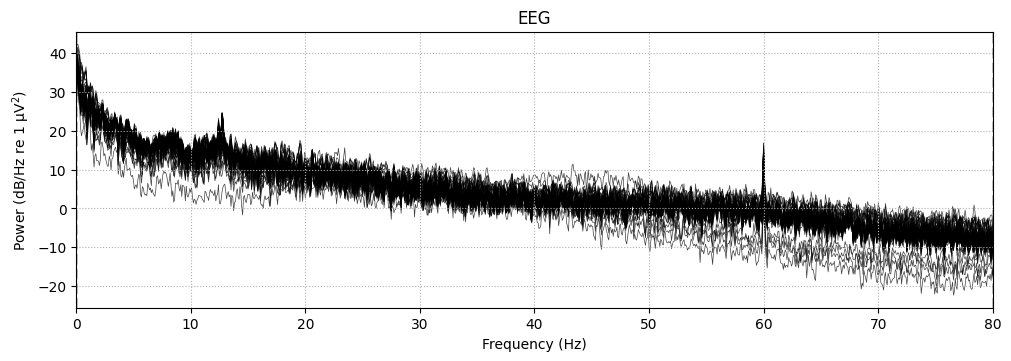

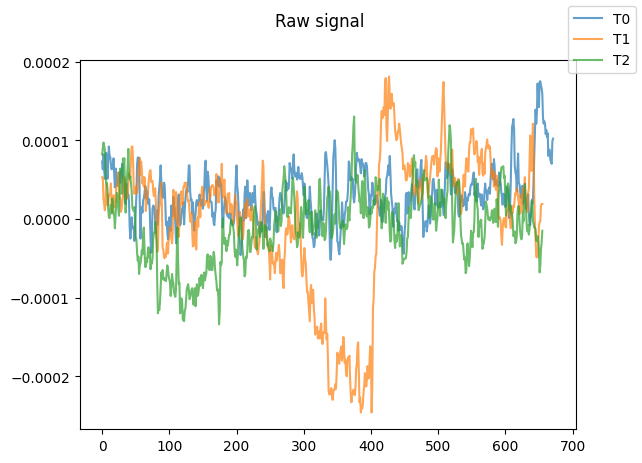

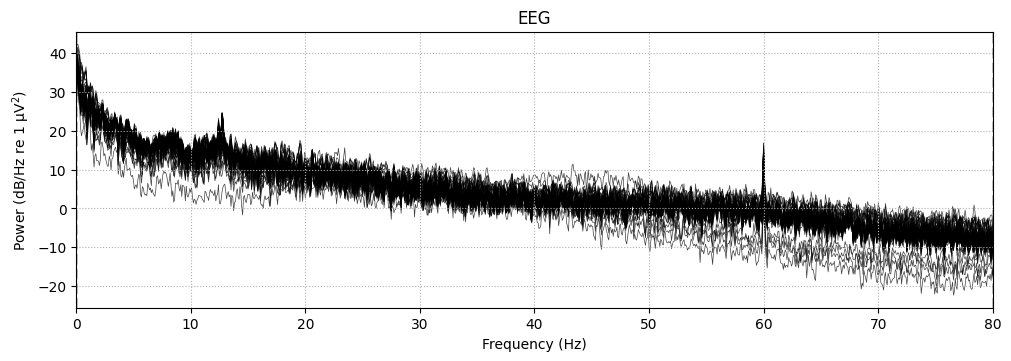

In [29]:
fig, sig_plt = plt.subplots(1, 1)
fig.suptitle('Raw signal')

first_t0, time_t0 = next((event.arr, event.time) for event in split_events if event.type_str == 'T0')
first_t1, time_t1 = next((event.arr, event.time) for event in split_events if event.type_str == 'T1')
first_t2, time_t2 = next((event.arr, event.time) for event in split_events if event.type_str == 'T2')

sig_plt.plot(first_t0[0], label='T0', alpha=0.7)
sig_plt.plot(first_t1[0], label='T1', alpha=0.7)
sig_plt.plot(first_t2[0], label='T2', alpha=0.7)

fig.legend()

raw.compute_psd(fmax=80).plot()

# for event in (event.arr for event in split_events):
#     sig_plt.plot(event)

## Filter data
We can see that there is a lot of information on the raw data, but there is also a lot of noises.

Now, the goal is to remove as much noise as possible.

To see where the noise come from, we'll use the Fourier Transform. It's a formula that transform signal on the time axis, into spectrum on the frequency axis. With it, we can see which frequencies are more present than the other, and filter to only keep them.

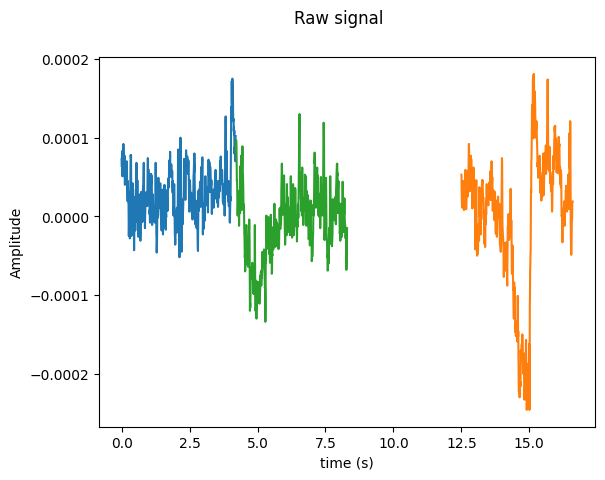

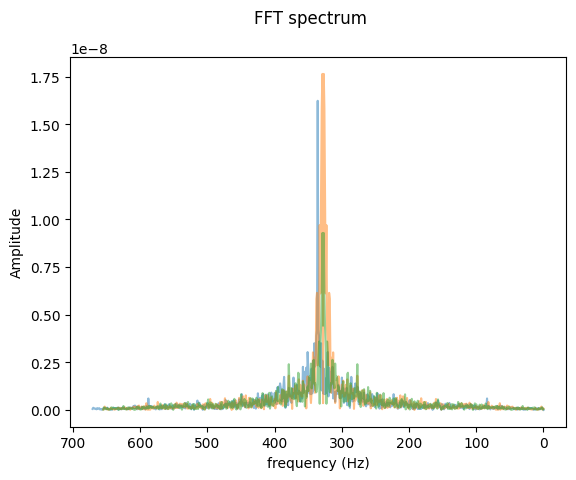

In [24]:

fig, sig_plt = plt.subplots(1, 1)
fig.suptitle('Raw signal')
sig_plt.plot(time_t0, first_t0[0], label='T0')
sig_plt.plot(time_t1, first_t1[0], label='T1')
sig_plt.plot(time_t2, first_t2[0], label='T2')
sig_plt.set_xlabel('time (s)')
sig_plt.set_ylabel('Amplitude')

fig, fft_plt = plt.subplots(1, 1)
fig.suptitle('FFT spectrum')
# Since fft need imaginary numbers, if not provided it mirror the values.
# The first half is the positive component, and the last half is the negative components.

x_axis_val = np.arange(-raw.info["sfreq"], raw.info["sfreq"], (raw.info["sfreq"] * 2) / data.shape[1])

fft_t0 = np.abs(np.fft.fftshift(np.fft.fft(first_t0[0]))) / data.size
fft_t1 = np.abs(np.fft.fftshift(np.fft.fft(first_t1[0]))) / data.size
fft_t2 = np.abs(np.fft.fftshift(np.fft.fft(first_t2[0]))) / data.size
fft_plt.plot(fft_t0.real, alpha=0.5)
fft_plt.plot(fft_t1.real, alpha=0.5)
fft_plt.plot(fft_t2.real, alpha=0.5)
fft_plt.xaxis.set_inverted(True)
fft_plt.set_xlabel('frequency (Hz)')
fft_plt.set_ylabel('Amplitude')
# fft_plt.plot(np.random.uniform(-160, 160, data.shape[1]), fft_data.real)
plt.show()


With this spectrum, we can see that the majority of the data is at a low frequency (Center of the plot).

We're lucky, because there is a signal filtering algorithm that remove the high frequencies and keep only the low ones.

It's called the **_Low Pass Filter_**.

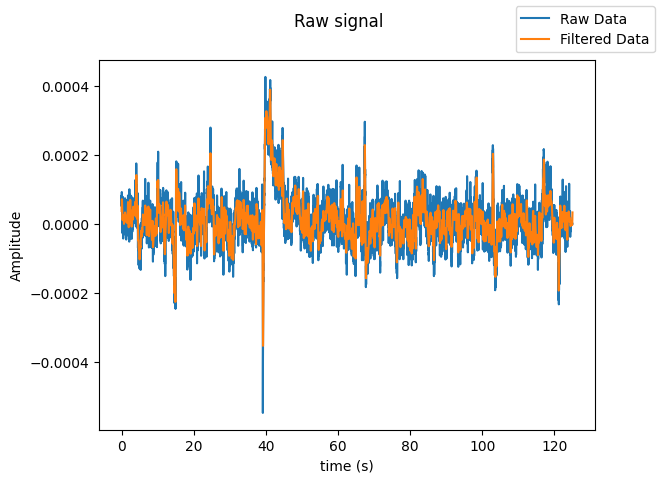

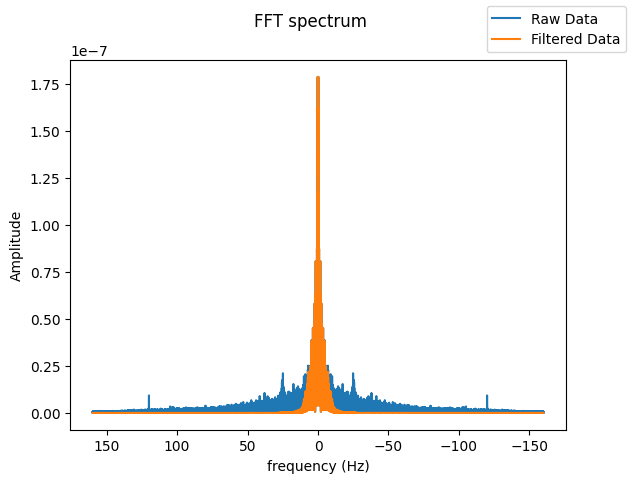

In [11]:
filtered_data = low_pass_filter(data[0:1, :], 500)[0]

fig, sig_plt = plt.subplots(1, 1)
fig.suptitle('Raw signal')

sig_plt.plot(raw.times, data[0, :], label="Raw Data")
sig_plt.plot(raw.times, filtered_data, label="Filtered Data")
sig_plt.set_xlabel('time (s)')
sig_plt.set_ylabel('Amplitude')

fig.legend()

fig, fft_plt = plt.subplots(1, 1)
fig.suptitle('FFT spectrum')
# Since fft need imaginary numbers, if not provided it mirror the values.
# The first half is the positive component, and the last half is the negative components.

x_axis_val = np.arange(-raw.info["sfreq"], raw.info["sfreq"], (raw.info["sfreq"] * 2) / data.shape[1])

fft_data = np.abs(np.fft.fftshift(np.fft.fft(data[0, :]))) / data.size
fft_filtered_data = np.abs(np.fft.fftshift(np.fft.fft(filtered_data))) / data.size
fft_plt.plot(x_axis_val, fft_data.real, label="Raw Data")
fft_plt.plot(x_axis_val, fft_filtered_data.real, label="Filtered Data")
fft_plt.xaxis.set_inverted(True)
fft_plt.set_xlabel('frequency (Hz)')
fft_plt.set_ylabel('Amplitude')

fig.legend()
# fft_plt.plot(np.random.uniform(-160, 160, data.shape[1]), fft_data.real)
plt.show()

Like showed here, on the FFT spectrum, the filtered data keep only low frequency and smoothly remove the higher frequencies.

On the signal plot, the signal is more clear and have less movement. We kept only the important parts.

Now, we can apply the filter over all the signals and save them.

In [18]:
data_folder = pth.Path('eeg-motor-movementimagery-dataset-1.0.0/files')
save_folder = pth.Path('filtered_data')

save_folder.mkdir(parents=True, exist_ok=True)

for patient_folder in data_folder.iterdir():
    for p_test in patient_folder.iterdir():
        if re.search(r".edf$", p_test.name) is None:
            continue
        filtered_data = low_pass_filter(mne.io.read_raw_edf(p_test).get_data(), 500)
        (save_folder / patient_folder.name).mkdir(parents=True, exist_ok=True)
        np.save(save_folder / patient_folder.name / p_test.name, filtered_data)
        print(f"Saved {patient_folder.name}/{p_test.name}")
    print(f"Finished patient {patient_folder.name}")


Saved S008/S008R11.edf
Saved S008/S008R04.edf
Saved S008/S008R13.edf
Saved S008/S008R06.edf
Finished patient S008
Saved S024/S024R06.edf
Saved S024/S024R12.edf
Saved S024/S024R14.edf
Saved S024/S024R09.edf
Saved S024/S024R13.edf
Saved S024/S024R11.edf
Saved S024/S024R03.edf
Saved S024/S024R01.edf
Saved S024/S024R05.edf
Saved S024/S024R08.edf
Saved S024/S024R04.edf
Saved S024/S024R02.edf
Saved S024/S024R10.edf
Saved S024/S024R07.edf
Finished patient S024
Saved S076/S076R13.edf
Saved S076/S076R06.edf
Saved S076/S076R09.edf
Saved S076/S076R10.edf
Saved S076/S076R05.edf
Saved S076/S076R02.edf
Saved S076/S076R08.edf
Saved S076/S076R01.edf
Saved S076/S076R04.edf
Saved S076/S076R11.edf
Saved S076/S076R12.edf
Saved S076/S076R07.edf
Saved S076/S076R03.edf
Saved S076/S076R14.edf
Finished patient S076
Saved S102/S102R09.edf
Saved S102/S102R01.edf
Saved S102/S102R04.edf
Saved S102/S102R06.edf
Saved S102/S102R12.edf
Saved S102/S102R07.edf
Saved S102/S102R10.edf
Saved S102/S102R11.edf
Saved S102/S10

KeyboardInterrupt: 